# HOMEWORK 12

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

In [2]:
import os
import cv2
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 1

Download the dataset ([link](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)) and unzip it.

### Step 2

For this homework, you will be working with the training set. Check out the `Train.csv`, open it and see what it contains. Load the dataset and plot random samples.

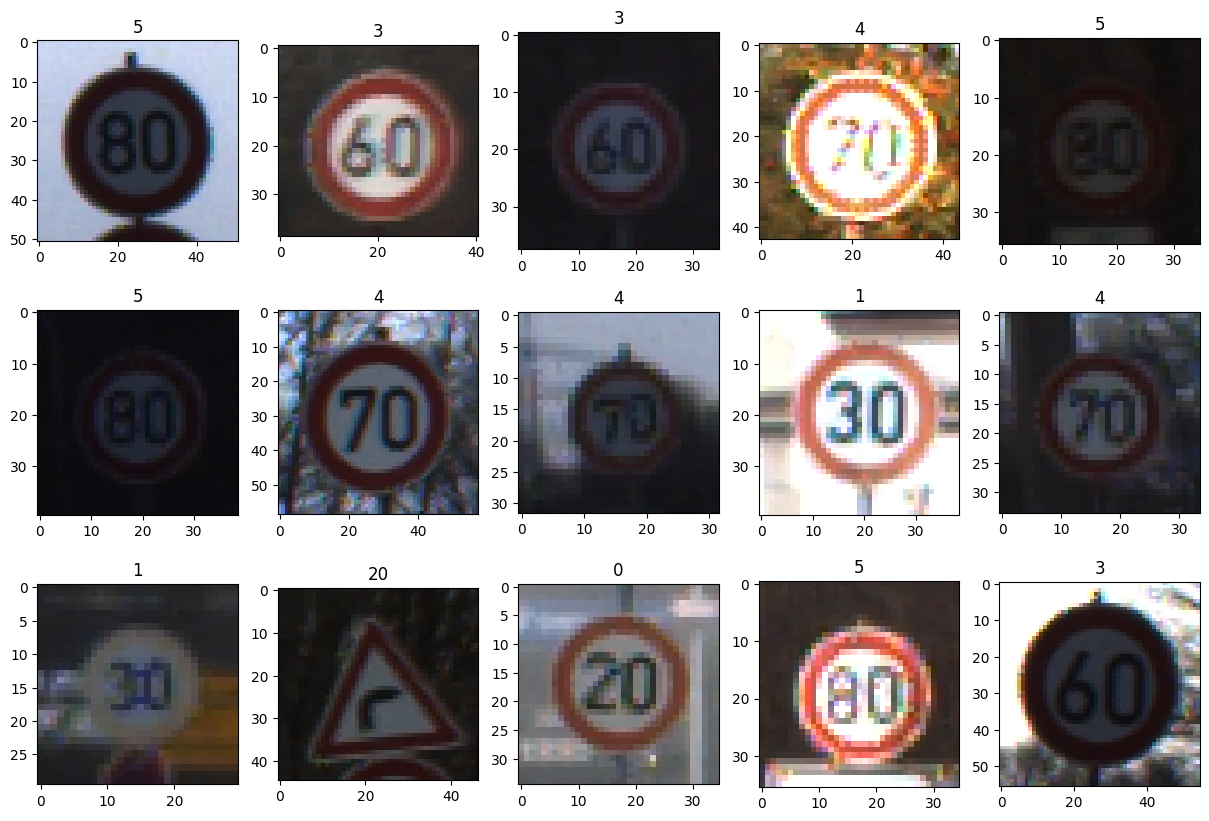

In [14]:
# Load the training labels
root = 'data/' # Path to the dataset location, e.g., '/data/janko/dataset/GTSRB'
data = pd.read_csv(os.path.join(root, 'Train.csv'))

# Number of training samples (amount of samples in data)
num_samples = 10000

# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    # Load image
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    # Convert image to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Show image
    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId'])

### Step 3

Inspect the dataset by computing and plotting the per-class histogram.

In [ ]:
# Extract class identifiers
# Hint: Check the csv 
ids = data['ClassId'].to_list()

Compute the per class histogram. You can use any approach you want (e.g. `numpy`). It's also worth looking at the `Counter` function from the `collections` module ([link](https://docs.python.org/3/library/collections.html#collections.Counter)) ;-)

(Text(0.5, 0, 'Traffic Sign ID'), Text(0, 0.5, 'Counts'))

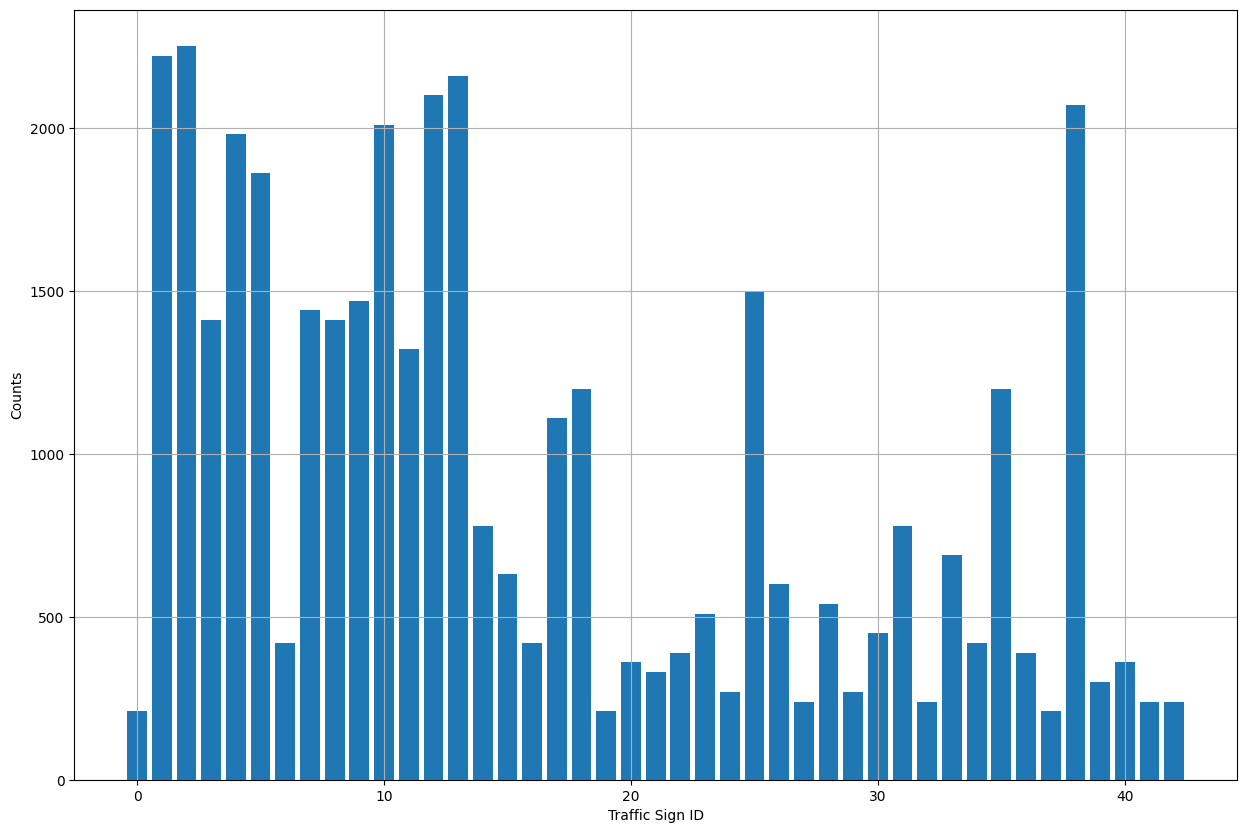

In [5]:
from collections import Counter
hist = Counter(ids)

plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')

### Questions

Please answer the following questions:
* Do you consider the dataset to be balanced? If so, why? If not, why?
* Are there any classes that are (significantly) over-represented or under-represeneted?

###### 1. No, becasue the dataset has some of the traffic signs with amount of image more than 1500 and some with less than 500, as it is a huge difference I consider it as non-balanced
###### 2. Yes, as we see from the histogram there are 6 classes with more than 2000 images and if we look below 500 there are about 9 clasess with about 250 images.

### Optional

Perform a further analysis on the dataset and draw some conclusion from it.

Hint 1: Unlike MNIST or CIFAR10, this dataset contains images with various spatial resolutions. Is there anything we can tell about the resolution distribution?
Hint 2: What about the brightness distribution? Are there classes there are significantly more bright than others?

In [7]:
import seaborn as sns

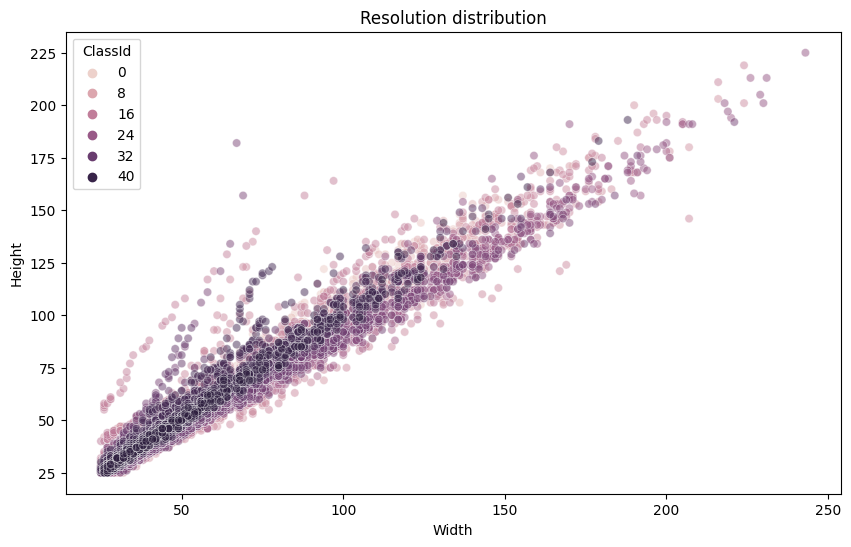

In [23]:
result = []
for label in os.listdir(root):
    class_path = os.path.join(root, label)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            
            if img is not None:
                h, w = img.shape[:2] 
                
                result.append({
                    'label': label, 
                    'width': w, 
                    'height': h, 
                    'aspect_ratio': w / h
                })

df_res = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_res, x='Width', y='Height', hue='ClassId', alpha=0.5)
plt.title("Resolution distribution")
plt.show()

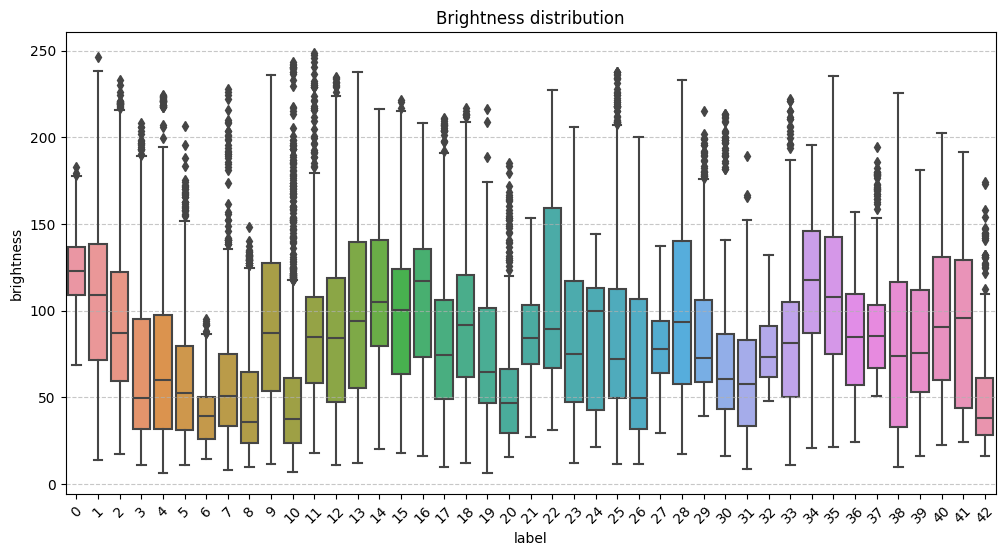

In [17]:
def get_brightness(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.mean(gray)

df_res = pd.DataFrame()
df_res['label'] = data['ClassId']
df_res['brightness'] = [get_brightness(os.path.join(root, r)) for r in data['Path']]
df_res = df_res.dropna()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_res, x='label', y='brightness')
plt.xticks(rotation=45)
plt.title("Brightness distribution")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()